# Author Lifecycle Analysis - Focused Component Testing

This notebook analyzes author collaboration outcomes in isolation, allowing you to:
- Test parameter changes locally before full simulation
- Understand statistical distributions of author success/failure
- Optimize parameters for desired outcome profiles

**All parameters are pulled from `author_collaboration_parameters.py`**

## Setup

In [1]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List, Dict

# Add parent directory to path
sys.path.insert(0, os.path.abspath('../..'))

# Import existing components (leverage existing code!)
from components.author_collaboration.author_collaboration_manager import AuthorCollaborationManager
from components.author_collaboration.author_factory import AuthorFactory
from components.author_collaboration.author_collaboration_parameters import AuthorCollaborationParameters as ACP
from components.strategy_lifecycle.strategy_manager import StrategyManager

print("✅ Imports successful")
print(f"\nCurrent parameters from author_collaboration_parameters.py:")
print(f"  Research duration: {ACP.AUTHOR_RESEARCH_DURATION_MIN}-{ACP.AUTHOR_RESEARCH_DURATION_MAX} quarters")
print(f"  Invention probability: {ACP.AUTHOR_INVENTION_PROBABILITY_MIN}-{ACP.AUTHOR_INVENTION_PROBABILITY_MAX}")
print(f"  Improvement probability: {ACP.AUTHOR_IMPROVEMENT_PROBABILITY_MIN}-{ACP.AUTHOR_IMPROVEMENT_PROBABILITY_MAX}")
print(f"  Group size: {ACP.GROUP_SIZE_MIN}-{ACP.GROUP_SIZE_MAX}")
print(f"  Improve return probability: {ACP.PROB_OF_IMPROVE_RETURN}")
print(f"  Improve capacity probability: {ACP.PROB_OF_IMPROVE_CAPACITY}")

✅ Imports successful

Current parameters from author_collaboration_parameters.py:
  Research duration: 2-4 quarters
  Invention probability: 0.1-0.5
  Improvement probability: 0.7-0.99
  Group size: 1-3
  Improve return probability: 0.9
  Improve capacity probability: 0.1


## Simulation Parameters (Only 2 tunable values!)

In [2]:
# ONLY TUNABLE PARAMETERS IN THIS NOTEBOOK
NUM_AUTHORS = 10          # How many authors to seed initially
NUM_SIMULATIONS = 100     # How many simulation runs
RANDOM_SEED = 42          # For reproducibility

print(f"Running {NUM_SIMULATIONS} simulations with {NUM_AUTHORS} initial authors")
print(f"Each simulation runs until all authors in the cohort retire (2-4 quarters max)")

Running 100 simulations with 10 initial authors
Each simulation runs until all authors in the cohort retire (2-4 quarters max)


## Simulation Runner (Leverages Existing Code)

In [3]:
def run_single_simulation(num_authors: int, seed: int) -> Dict:
    """
    Run a single author lifecycle simulation until all authors retire.
    Uses existing AuthorCollaborationManager and StrategyManager.
    
    Includes seed strategies to provide improvement opportunities.
    Tracks ONLY the initial cohort, not any authors hired during simulation.
    """
    random.seed(seed)
    np.random.seed(seed)
    
    # Initialize components (existing code)
    author_manager = AuthorCollaborationManager()
    strategy_manager = StrategyManager()
    
    # Create seed strategy BEFORE hiring authors (so they have something to improve)
    from components.strategy_lifecycle.strategy_factory import StrategyFactory
    
    # Create a virtual "founder" author who owns the seed strategies
    founder = AuthorFactory.create_new_author(hire_quarter=0)
    founder.author_id = "founder"
    founder.name = "Founder"
    
    # Create 2 seed strategies owned by founder
    seed_strategy_1 = StrategyFactory.create_new_strategy(
        authors=[founder],
        quarter=0,
        strategy_id="seed_strategy_1"
    )
    seed_strategy_1.active_capacity = seed_strategy_1.max_capacity
    strategy_manager.add_strategy(seed_strategy_1)
    
    seed_strategy_2 = StrategyFactory.create_new_strategy(
        authors=[founder],
        quarter=0,
        strategy_id="seed_strategy_2"
    )
    seed_strategy_2.active_capacity = seed_strategy_2.max_capacity
    strategy_manager.add_strategy(seed_strategy_2)
    
    # Create initial authors (existing factory)
    initial_authors = AuthorFactory.create_test_author_pool(num_authors, hire_quarter=0)
    
    # Store initial cohort IDs and durations
    cohort_author_ids = set()
    author_durations = {}
    for author in initial_authors:
        author_manager.add_author(author)
        cohort_author_ids.add(author.author_id)
        author_durations[author.author_id] = author.remaining_research_quarters
    
    # Track max research duration to know when all retire
    max_duration = max(author_durations.values())
    
    # Run simulation until all authors retire
    quarter = 1
    all_activities = []
    
    while quarter <= max_duration:
        # Use existing process_quarterly_collaboration_cycle
        # NOTE: This may hire new authors, but we only track the initial cohort
        # Use None for current_aum to default to strategy capacity (prevents excessive hiring)
        activities, stats = author_manager.process_quarterly_collaboration_cycle(
            quarter=quarter,
            strategy_manager=strategy_manager,
            current_aum=None
        )
        all_activities.extend(activities)
        quarter += 1
    
    # Collect results - ONLY track initial cohort authors
    all_authors = author_manager.get_all_authors()
    cohort_authors = [a for a in all_authors if a.author_id in cohort_author_ids]
    
    results = {
        'authors': cohort_authors,
        'author_durations': author_durations,
        'activities': all_activities,
        'strategies_created': len([s for s in strategy_manager.get_all_strategies() 
                                   if s.strategy_id not in ['seed_strategy_1', 'seed_strategy_2']]),
        'total_quarters': quarter - 1
    }
    
    return results

print("✅ Simulation runner defined (with 2 seed strategies for improvement opportunities)")

✅ Simulation runner defined (with 2 seed strategies for improvement opportunities)


## Run All Simulations

In [4]:
print(f"Running {NUM_SIMULATIONS} simulations...")
all_simulation_results = []

for sim_num in range(NUM_SIMULATIONS):
    seed = RANDOM_SEED + sim_num
    result = run_single_simulation(NUM_AUTHORS, seed)
    all_simulation_results.append(result)
    
    if (sim_num + 1) % 20 == 0:
        print(f"  Completed {sim_num + 1}/{NUM_SIMULATIONS}")

print(f"\n✅ All {NUM_SIMULATIONS} simulations complete!")

Running 100 simulations...
  Completed 20/100
  Completed 40/100
  Completed 60/100
  Completed 80/100
  Completed 100/100

✅ All 100 simulations complete!


## Analysis 1: Author Success Rate

**Key Question:** How many authors contribute successfully vs. fail completely?

📊 Author Success Analysis
Total authors across all simulations: 1000
Authors with ≥1 contribution: 981 (98.1%)
Authors with 0 contributions (failures): 19 (1.9%)


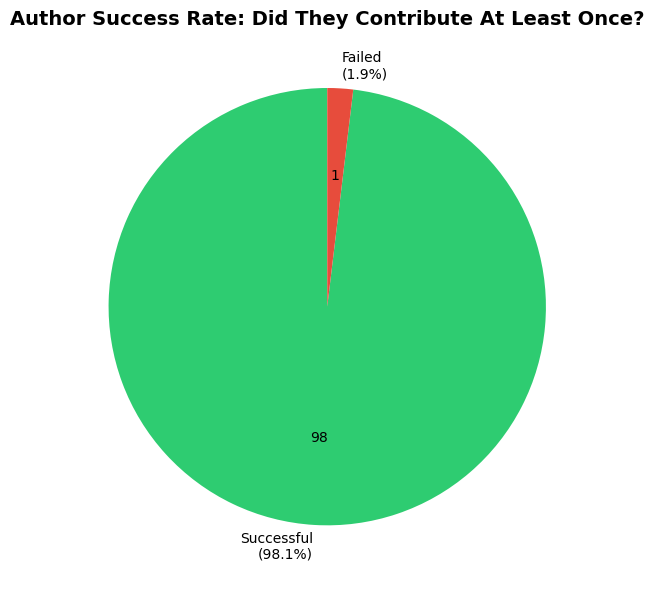

In [5]:
# Analyze author contribution rates
author_contribution_stats = []

for sim_result in all_simulation_results:
    author_durations = sim_result['author_durations']
    for author in sim_result['authors']:
        total_contributions = len(author.strategies_created) + len(author.strategies_improved)
        research_duration = author_durations.get(author.author_id, 0)
        author_contribution_stats.append({
            'total_contributions': total_contributions,
            'strategies_created': len(author.strategies_created),
            'strategies_improved': len(author.strategies_improved),
            'research_duration': research_duration,
            'invention_probability': author.invention_probability,
            'improvement_probability': author.improvement_probability,
            'has_contributed': total_contributions > 0
        })

df_authors = pd.DataFrame(author_contribution_stats)

# Calculate key metrics
total_authors = len(df_authors)
successful_authors = df_authors['has_contributed'].sum()
failed_authors = total_authors - successful_authors
success_rate = successful_authors / total_authors

print(f"📊 Author Success Analysis")
print(f"="*50)
print(f"Total authors across all simulations: {total_authors}")
print(f"Authors with ≥1 contribution: {successful_authors} ({success_rate:.1%})")
print(f"Authors with 0 contributions (failures): {failed_authors} ({1-success_rate:.1%})")

# Visualize - just the pie chart
fig, ax = plt.subplots(figsize=(8, 6))

ax.pie([successful_authors, failed_authors], 
       labels=[f'Successful\n({success_rate:.1%})', f'Failed\n({1-success_rate:.1%})'],
       autopct='%d', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax.set_title('Author Success Rate: Did They Contribute At Least Once?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Analysis 2: Activity Breakdown

**Key Question:** What types of activities occur and how successful are they?

📊 Activity Breakdown

Inventions:
  Attempted: 587
  Succeeded: 222 (37.8%)
  Failed: 365 (62.2%)

Improvements:
  Attempted: 977
  Succeeded: 841 (86.1%)
    - Return improvements: 705
    - Capacity improvements: 136
  Failed: 136 (13.9%)


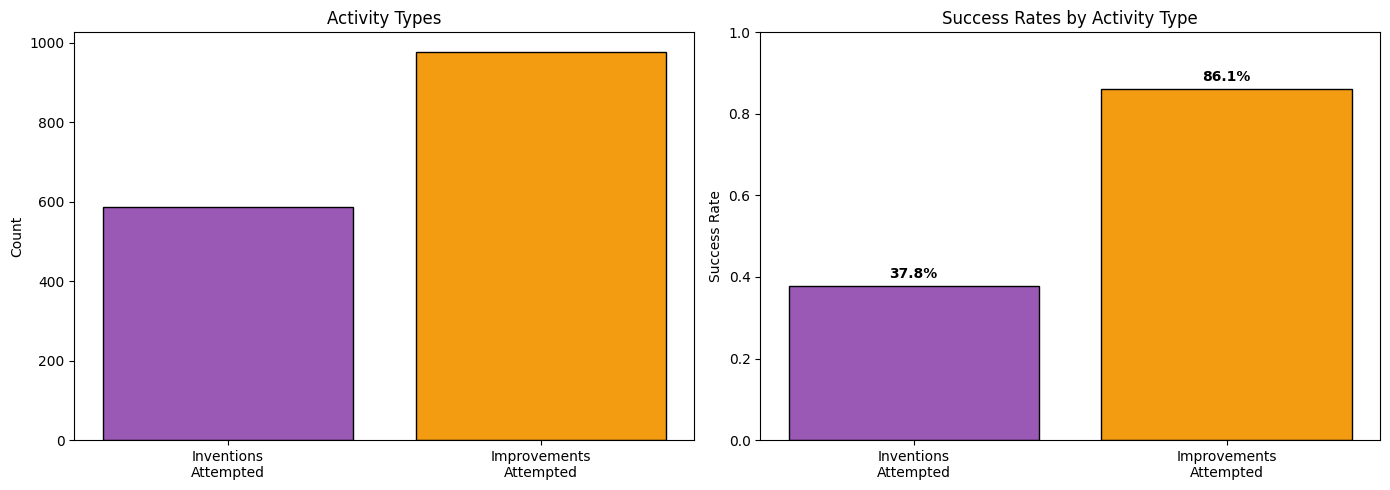

In [6]:
# Analyze all activities
activity_stats = defaultdict(int)

for sim_result in all_simulation_results:
    for activity in sim_result['activities']:
        activity_type = activity.activity_type
        success = activity.success
        
        if activity_type == 'invention_start':
            activity_stats['inventions_started'] += 1
        elif activity_type == 'invention_complete':
            activity_stats['inventions_attempted'] += 1
            if success:
                activity_stats['inventions_succeeded'] += 1
            else:
                activity_stats['inventions_failed'] += 1
        elif activity_type == 'improvement':
            activity_stats['improvements_attempted'] += 1
            if success:
                activity_stats['improvements_succeeded'] += 1
                if activity.improvement_type == 'return':
                    activity_stats['improved_return'] += 1
                elif activity.improvement_type == 'capacity':
                    activity_stats['improved_capacity'] += 1
            else:
                activity_stats['improvements_failed'] += 1

# Calculate success rates
invention_success_rate = (activity_stats['inventions_succeeded'] / 
                          activity_stats['inventions_attempted'] if activity_stats['inventions_attempted'] > 0 else 0)
improvement_success_rate = (activity_stats['improvements_succeeded'] / 
                            activity_stats['improvements_attempted'] if activity_stats['improvements_attempted'] > 0 else 0)

print(f"📊 Activity Breakdown")
print(f"="*50)
print(f"\nInventions:")
print(f"  Attempted: {activity_stats['inventions_attempted']}")
print(f"  Succeeded: {activity_stats['inventions_succeeded']} ({invention_success_rate:.1%})")
print(f"  Failed: {activity_stats['inventions_failed']} ({1-invention_success_rate:.1%})")

print(f"\nImprovements:")
print(f"  Attempted: {activity_stats['improvements_attempted']}")
print(f"  Succeeded: {activity_stats['improvements_succeeded']} ({improvement_success_rate:.1%})")
print(f"    - Return improvements: {activity_stats['improved_return']}")
print(f"    - Capacity improvements: {activity_stats['improved_capacity']}")
print(f"  Failed: {activity_stats['improvements_failed']} ({1-improvement_success_rate:.1%})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activity type distribution
activity_types = ['Inventions\nAttempted', 'Improvements\nAttempted']
activity_counts = [activity_stats['inventions_attempted'], activity_stats['improvements_attempted']]
axes[0].bar(activity_types, activity_counts, color=['#9b59b6', '#f39c12'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Activity Types')

# Success rates comparison
success_rates = [invention_success_rate, improvement_success_rate]
axes[1].bar(activity_types, success_rates, color=['#9b59b6', '#f39c12'], edgecolor='black')
axes[1].set_ylabel('Success Rate')
axes[1].set_title('Success Rates by Activity Type')
axes[1].set_ylim(0, 1)
for i, rate in enumerate(success_rates):
    axes[1].text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Analysis 3: Temporal Patterns

**Key Question:** When do successful contributions occur during an author's tenure?

📊 Temporal Patterns
Total contributions tracked: 2910

Contributions by relative quarter:
relative_quarter
1     900
2    1003
3     681
4     326
Name: count, dtype: int64


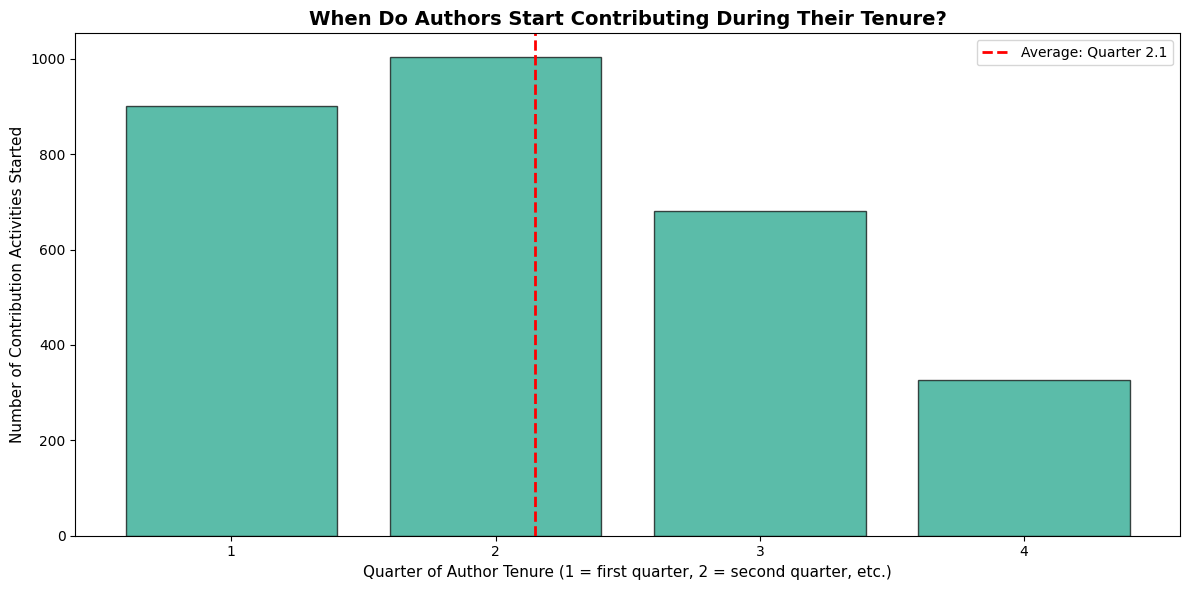

In [7]:
# Analyze contribution timing using activity data
contribution_quarters = []

for sim_result in all_simulation_results:
    author_durations = sim_result['author_durations']
    for activity in sim_result['activities']:
        # Track successful activities OR invention starts (which begin a contribution)
        if activity.success or activity.activity_type == 'invention_start':
            quarter = activity.quarter
            # For each group member
            for author_id in activity.group_members:
                # Find the author to get hire quarter
                author = next((a for a in sim_result['authors'] if a.author_id == author_id), None)
                if author:
                    # Calculate relative quarter (1 = first quarter, etc.)
                    relative_quarter = quarter - author.hire_quarter
                    research_duration = author_durations.get(author_id, 0)
                    if relative_quarter > 0 and relative_quarter <= research_duration:
                        contribution_quarters.append({
                            'absolute_quarter': quarter,
                            'relative_quarter': relative_quarter,
                            'research_duration': research_duration,
                            'activity_type': activity.activity_type
                        })

df_timing = pd.DataFrame(contribution_quarters)

if len(df_timing) > 0:
    print(f"📊 Temporal Patterns")
    print(f"="*50)
    print(f"Total contributions tracked: {len(df_timing)}")
    print(f"\nContributions by relative quarter:")
    print(df_timing['relative_quarter'].value_counts().sort_index())
    
    # Visualize with bars for all possible quarters (1 to max_duration)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    max_quarter = int(df_timing['relative_quarter'].max())
    all_quarters = range(1, max_quarter + 1)
    counts = df_timing['relative_quarter'].value_counts().reindex(all_quarters, fill_value=0)
    
    ax.bar(all_quarters, counts, edgecolor='black', alpha=0.7, color='#16a085')
    ax.set_xlabel('Quarter of Author Tenure (1 = first quarter, 2 = second quarter, etc.)', fontsize=11)
    ax.set_ylabel('Number of Contribution Activities Started', fontsize=11)
    ax.set_title('When Do Authors Start Contributing During Their Tenure?', fontsize=14, fontweight='bold')
    ax.axvline(df_timing['relative_quarter'].mean(), color='red', 
               linestyle='--', linewidth=2, label=f"Average: Quarter {df_timing['relative_quarter'].mean():.1f}")
    ax.set_xticks(all_quarters)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No contributions found in simulations")

## Analysis 4: Does Research Duration Impact Success?

**Key Question:** Do authors with longer research periods (more quarters) contribute more successfully?

Since authors have different research durations (2-4 quarters), we want to know:
- Does having 4 quarters give better success than 2 quarters?
- How does duration affect average contributions?

📊 Research Duration Impact Analysis

Breakdown by Research Duration (in quarters):
                   Successful Authors  Total Authors  Success Rate  \
research_duration                                                    
2                                 312            325         0.960   
3                                 325            330         0.985   
4                                 344            345         0.997   

                   Avg Contributions  
research_duration                     
2                              1.366  
3                              1.879  
4                              2.319  

Interpretation:
• 'Total Authors' = How many authors had this research duration
• 'Successful Authors' = How many of them contributed at least once
• 'Success Rate' = Percentage who contributed (higher is better)
• 'Avg Contributions' = Average number of contributions per author


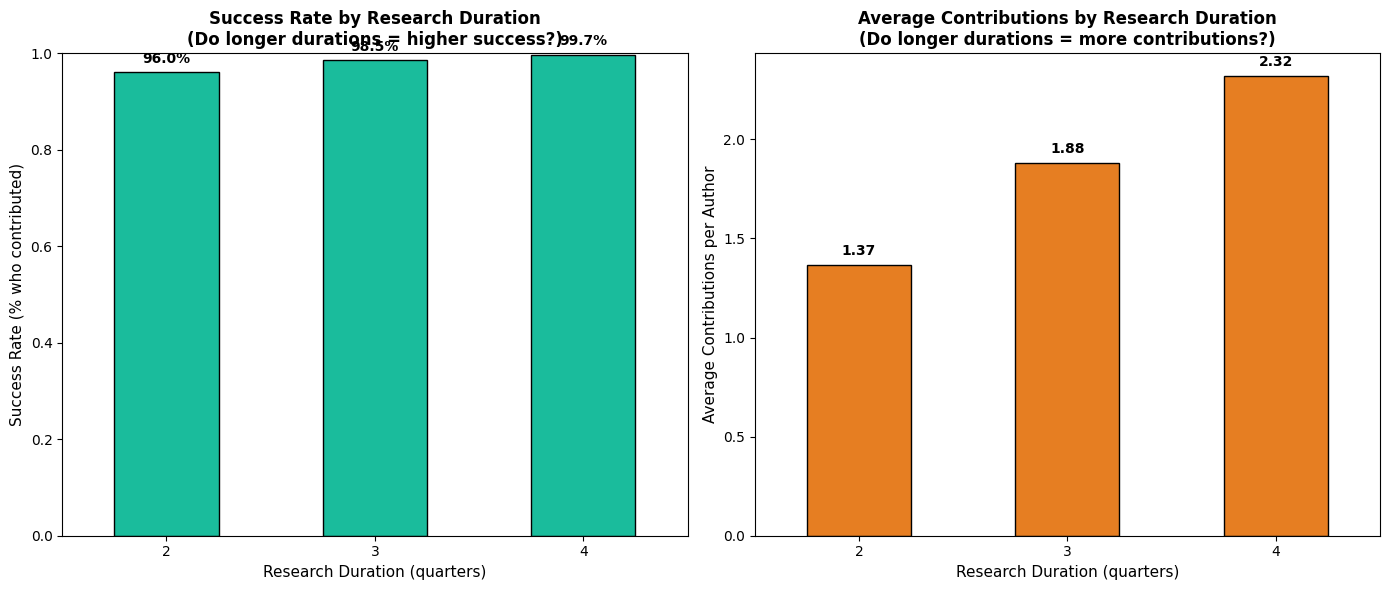


💡 Key Insight: Authors with 4 quarters of research have the highest success rate (99.7%)


In [8]:
# Group authors by their research duration
duration_success = df_authors.groupby('research_duration').agg({
    'has_contributed': ['sum', 'count', 'mean'],
    'total_contributions': 'mean'
}).round(3)

duration_success.columns = ['Successful Authors', 'Total Authors', 'Success Rate', 'Avg Contributions']

print(f"📊 Research Duration Impact Analysis")
print(f"="*50)
print(f"\nBreakdown by Research Duration (in quarters):")
print(duration_success)
print(f"\nInterpretation:")
print(f"• 'Total Authors' = How many authors had this research duration")
print(f"• 'Successful Authors' = How many of them contributed at least once")
print(f"• 'Success Rate' = Percentage who contributed (higher is better)")
print(f"• 'Avg Contributions' = Average number of contributions per author")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Success rate by duration
duration_success['Success Rate'].plot(kind='bar', ax=axes[0], color='#1abc9c', edgecolor='black')
axes[0].set_xlabel('Research Duration (quarters)', fontsize=11)
axes[0].set_ylabel('Success Rate (% who contributed)', fontsize=11)
axes[0].set_title('Success Rate by Research Duration\n(Do longer durations = higher success?)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)
# Add percentage labels on bars
for i, v in enumerate(duration_success['Success Rate']):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Average contributions by duration
duration_success['Avg Contributions'].plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_xlabel('Research Duration (quarters)', fontsize=11)
axes[1].set_ylabel('Average Contributions per Author', fontsize=11)
axes[1].set_title('Average Contributions by Research Duration\n(Do longer durations = more contributions?)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
# Add value labels on bars
for i, v in enumerate(duration_success['Avg Contributions']):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary insight
best_duration = duration_success['Success Rate'].idxmax()
best_rate = duration_success.loc[best_duration, 'Success Rate']
print(f"\n💡 Key Insight: Authors with {int(best_duration)} quarters of research have the highest success rate ({best_rate:.1%})")